In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("/Users/athulbenny/Desktop/kidney_disease_dataset.csv")


In [4]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())

Dataset Shape: (2304, 9)

First 5 Rows:
    Age  Creatinine_Level   BUN  Diabetes  Hypertension   GFR  Urine_Output  \
0   71              0.30  40.9         0             1  46.8        1622.0   
1   34              1.79  17.1         0             0  43.8        1428.0   
2   80              2.67  15.0         0             1  78.2        1015.0   
3   40              0.97  31.1         0             1  92.8        1276.0   
4   43              2.05  22.8         1             1  62.2        1154.0   

   CKD_Status  Dialysis_Needed  
0           1                0  
1           1                0  
2           1                0  
3           1                0  
4           0                0  


In [5]:
df.replace('?', np.nan, inplace=True)


In [9]:
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

In [10]:
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

In [11]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

print("\nMissing Values After Cleaning:\n", df.isnull().sum())



Missing Values After Cleaning:
 Age                 0
Creatinine_Level    0
BUN                 0
Diabetes            0
Hypertension        0
GFR                 0
Urine_Output        0
CKD_Status          0
Dialysis_Needed     0
dtype: int64


/var/folders/w1/4c331bwn1834db27543n050c0000gn/T/ipykernel_1157/42089312.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [12]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [14]:
print(df.columns)

Index(['Age', 'Creatinine_Level', 'BUN', 'Diabetes', 'Hypertension', 'GFR',
       'Urine_Output', 'CKD_Status', 'Dialysis_Needed'],
      dtype='object')


In [22]:
X = df.drop('CKD_Status', axis=1)
y = df['CKD_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 1843
Testing Samples: 461


In [23]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [24]:
y_pred = model.predict(X_test)

In [25]:
accuracy = accuracy_score(y_test, y_pred)

In [26]:
print("\n====================================")
print("MODEL PERFORMANCE")
print("====================================")
print("Accuracy:", accuracy)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


MODEL PERFORMANCE
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00       227

    accuracy                           1.00       461
   macro avg       1.00      1.00      1.00       461
weighted avg       1.00      1.00      1.00       461


Confusion Matrix:
 [[234   0]
 [  0 227]]


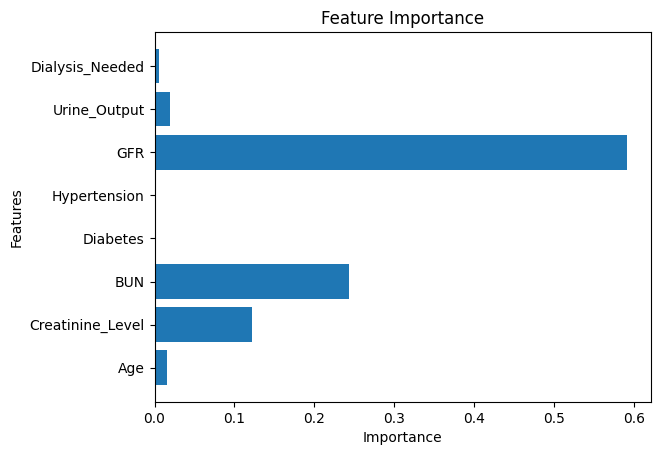

In [27]:
importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()


In [28]:
sample = X_test.iloc[0].values.reshape(1, -1)
prediction = model.predict(sample)

print("\n====================================")
print("SAMPLE PREDICTION")
print("====================================")

if prediction[0] == 0:
    print("Prediction: CKD (Kidney Disease)")
else:
    print("Prediction: NOT CKD (Healthy)")


SAMPLE PREDICTION
Prediction: NOT CKD (Healthy)


/Users/athulbenny/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
